# Install packages if necessary

In [ ]:
install.packages(c(
  "tidyverse",       # data manipulation and visualization
  "moments",         # skewness and kurtosis for EDA
  "survival",        # Surv() objects and core survival analysis tools
  "rpart",           # single decision / survival trees
  "gbm",             # boosting, including Cox PH survival boosting
  "ipred",           # bagging, including bagged survival trees
  "randomForestSRC"  # random forests for survival
))

Warning message:
"packages 'tidyverse', 'moments', 'survival', 'rpart', 'gbm', 'BART', 'ipred', 'randomForestSRC' are in use and will not be installed"


---

# Set seed (start top down run here)

In [1]:
# Set seed for reproducibility from top of file (top down running)
seed <- 999
set.seed(seed)

---

# Load libraries

In [ ]:
library(tidyverse)
library(moments)
library(survival)
library(rpart)
library(gbm)
library(ipred)
library(randomForestSRC)
library(xgboost)
library(Matrix) 

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'survival' was built under R version 4.5.3"
Warning message:
"package 'rpart' was built under R version 4.5.3"
Warning message:
"package 'gbm' was built under R version 4.5.3"
Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3

Warning message:
"package 'BART' was built under R version 4.

---

# Load data / Start EDA

In [3]:
raw_df <- read.csv("METABRIC_RNA_Mutation.csv")

# Explore data
head(raw_df)

cat("Number of rows:", nrow(raw_df), "\n",
    "Number of columns:", ncol(raw_df), "\n")

colnames(raw_df)

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_._claudin.low_subtype,cohort,er_status_measured_by_ihc,⋯,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,,0,claudin-low,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
2,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
3,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
4,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
5,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
6,10,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0


Number of rows: 1904 
 Number of columns: 693 


[1] "patient_id"                     "age_at_diagnosis"              
  [3] "type_of_breast_surgery"         "cancer_type"                   
  [5] "cancer_type_detailed"           "cellularity"                   
  [7] "chemotherapy"                   "pam50_._claudin.low_subtype"   
  [9] "cohort"                         "er_status_measured_by_ihc"     
 [11] "er_status"                      "neoplasm_histologic_grade"     
 [13] "her2_status_measured_by_snp6"   "her2_status"                   
 [15] "tumor_other_histologic_subtype" "hormone_therapy"               
 [17] "inferred_menopausal_state"      "integrative_cluster"           
 [19] "primary_tumor_laterality"       "lymph_nodes_examined_positive" 
 [21] "mutation_count"                 "nottingham_prognostic_index"   
 [23] "oncotree_code"                  "overall_survival_months"       
 [25] "overall_survival"               "pr_status"                     
 [27] "radio_therapy"                  "X3.gene_classifier_subtype"    
 [29] "tumor_size"                     "tumor_stage"                   
 [31] "death_from_cancer"              "brca1"                         
 [33] "brca2"                          "palb2"                         
 [35] "pten"                           "tp53"                          
 [37] "atm"                            "cdh1"                          
 [39] "chek2"                          "nbn"                           
 [41] "nf1"                            "stk11"                         
 [43] "bard1"                          "mlh1"                          
 [45] "msh2"                           "msh6"                          
 [47] "pms2"                           "epcam"                         
 [49] "rad51c"                         "rad51d"                        
 [51] "rad50"                          "rb1"                           
 [53] "rbl1"                           "rbl2"                          
 [55] "ccna1"                          "ccnb1"                         
 [57] "cdk1"                           "ccne1"                         
 [59] "cdk2"                           "cdc25a"                        
 [61] "ccnd1"                          "cdk4"                          
 [63] "cdk6"                           "ccnd2"                         
 [65] "cdkn2a"                         "cdkn2b"                        
 [67] "myc"                            "cdkn1a"                        
 [69] "cdkn1b"                         "e2f1"                          
 [71] "e2f2"                           "e2f3"                          
 [73] "e2f4"                           "e2f5"                          
 [75] "e2f6"                           "e2f7"                          
 [77] "e2f8"                           "src"                           
 [79] "jak1"                           "jak2"                          
 [81] "stat1"                          "stat2"                         
 [83] "stat3"                          "stat5a"                        
 [85] "stat5b"                         "mdm2"                          
 [87] "tp53bp1"                        "adam10"                        
 [89] "adam17"                         "aph1a"                         
 [91] "aph1b"                          "arrdc1"                        
 [93] "cir1"                           "ctbp1"                         
 [95] "ctbp2"                          "cul1"                          
 [97] "dll1"                           "dll3"                          
 [99] "dll4"                           "dtx1"                          
[101] "dtx2"                           "dtx3"                          
[103] "dtx4"                           "ep300"                         
[105] "fbxw7"                          "hdac1"                         
[107] "hdac2"                          "hes1"                          
[109] "hes5"                           "heyl"                          
[111] "itch"                           "ja

In [4]:
# Missing / empty / zero summary table

summary_table <- data.frame(
  variable = names(raw_df),
  na_count = sapply(raw_df, function(x) sum(is.na(x))),
  na_pct = sapply(raw_df, function(x) mean(is.na(x)) * 100),
  empty_string_count = sapply(raw_df, function(x) {
    if (is.character(x) || is.factor(x)) sum(trimws(as.character(x)) == "", na.rm = TRUE) else 0
  }),
  empty_string_pct = sapply(raw_df, function(x) {
    if (is.character(x) || is.factor(x)) mean(trimws(as.character(x)) == "", na.rm = TRUE) * 100 else 0
  }),
  zero_count = sapply(raw_df, function(x) {
    if (is.numeric(x)) sum(x == 0, na.rm = TRUE) else 0
  }),
  zero_pct = sapply(raw_df, function(x) {
    if (is.numeric(x)) mean(x == 0, na.rm = TRUE) * 100 else 0
  })
)

summary_table <- summary_table %>%
  mutate(across(-variable, ~ round(., 2)))

summary_table %>%
  filter(
    na_count > 0 |
    empty_string_count > 0 |
    zero_count > 0
  )

,variable,na_count,na_pct,empty_string_count,empty_string_pct,zero_count,zero_pct
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
patient_id,patient_id,0,0.00,0,0.00,1,0.05
type_of_breast_surgery,type_of_breast_surgery,0,0.00,22,1.16,0,0.00
cancer_type_detailed,cancer_type_detailed,0,0.00,15,0.79,0,0.00
cellularity,cellularity,0,0.00,54,2.84,0,0.00
chemotherapy,chemotherapy,0,0.00,0,0.00,1508,79.20
er_status_measured_by_ihc,er_status_measured_by_ihc,0,0.00,30,1.58,0,0.00
neoplasm_histologic_grade,neoplasm_histologic_grade,72,3.78,0,0.00,0,0.00
tumor_other_histologic_subtype,tumor_other_histologic_subtype,0,0.00,15,0.79,0,0.00
hormone_therapy,hormone_therapy,0,0.00,0,0.00,730,38.34


In [5]:
# Mean time to event by tumor stage (ignoring missing)
aggregate(
  raw_df$overall_survival_months ~ raw_df$tumor_stage,
  FUN = median,
  na.rm = TRUE
)

raw_df$tumor_stage,raw_df$overall_survival_months
<dbl>,<dbl>
0,95.30000
1,152.06667
2,108.33333
3,54.10000
4,48.53333


In [6]:
# Event distributions (alive or dead)
table(raw_df$overall_survival, useNA = "ifany")
table(raw_df$death_from_cancer, useNA = "ifany")


   0    1 
1103  801 


                          Died of Disease Died of Other Causes 
                   1                  622                  480 
              Living 
                 801 

In [7]:
# spotted typo, but will leave as is.
table(raw_df$er_status_measured_by_ihc, useNA = "ifany")
table(raw_df$er_status, useNA = "ifany")


         Negative  Positve 
      30      429     1445 


Negative Positive 
     445     1459 

---

# **Split high-dimensional dataset for easier pre-process**

In [8]:
clinical_vars <- raw_df %>%
  select(age_at_diagnosis:(brca1)) %>%
  select(-brca1)

gene_vars <- raw_df %>%
  select(brca1:pik3ca_mut) %>%
  select(-pik3ca_mut)

mutation_vars <- raw_df %>%
  select(ends_with("_mut"))

In [9]:
# Predictor variable counts by type
data.frame(
  group = c("Clinical", "Gene expression", "Mutation", "Total"),
  count = c(ncol(clinical_vars),
            ncol(gene_vars),
            ncol(mutation_vars),
            sum(ncol(clinical_vars), ncol(gene_vars), ncol(mutation_vars))
            )
)

group,count
<chr>,<int>
Clinical,30
Gene expression,489
Mutation,173
Total,692


### All 692 columns broken up into respective sub-dataset for easier pre-processing differing variable types.
- clinical_vars
- gene_vars
- mutation_vars

---

# **Pre-processing `clinical` predictor variables**

In [10]:
# Quick glance at shape, types, and classes 
str(clinical_vars)

'data.frame':	1904 obs. of  30 variables:
 $ age_at_diagnosis              : num  75.7 43.2 48.9 47.7 77 ...
 $ type_of_breast_surgery        : chr  "MASTECTOMY" "BREAST CONSERVING" "MASTECTOMY" "MASTECTOMY" ...
 $ cancer_type                   : chr  "Breast Cancer" "Breast Cancer" "Breast Cancer" "Breast Cancer" ...
 $ cancer_type_detailed          : chr  "Breast Invasive Ductal Carcinoma" "Breast Invasive Ductal Carcinoma" "Breast Invasive Ductal Carcinoma" "Breast Mixed Ductal and Lobular Carcinoma" ...
 $ cellularity                   : chr  "" "High" "High" "Moderate" ...
 $ chemotherapy                  : int  0 0 1 1 1 0 1 0 0 0 ...
 $ pam50_._claudin.low_subtype   : chr  "claudin-low" "LumA" "LumB" "LumB" ...
 $ cohort                        : num  1 1 1 1 1 1 1 1 1 1 ...
 $ er_status_measured_by_ihc     : chr  "Positve" "Positve" "Positve" "Positve" ...
 $ er_status                     : chr  "Positive" "Positive" "Positive" "Positive" ...
 $ neoplasm_histologic_grade     : n

In [11]:
# Replace blank strings with NA in character columns
clinical_vars <- clinical_vars %>%
  mutate(
    across(
      where(is.character),
      ~ {
        x <- trimws(.)
        x[x == ""] <- NA
        x
      }
    )
  )

In [12]:
# Check missingness in clinical variables
clinical_missing <- data.frame(
  variable = names(clinical_vars),
  missing = colSums(is.na(clinical_vars)),
  missing_pct = round(colMeans(is.na(clinical_vars)) * 100, 3)
)

# View missing data variables
clinical_missing <- clinical_missing[clinical_missing$missing > 0, ]
clinical_missing

,variable,missing,missing_pct
,<chr>,<dbl>,<dbl>
type_of_breast_surgery,type_of_breast_surgery,22,1.155
cancer_type_detailed,cancer_type_detailed,15,0.788
cellularity,cellularity,54,2.836
er_status_measured_by_ihc,er_status_measured_by_ihc,30,1.576
neoplasm_histologic_grade,neoplasm_histologic_grade,72,3.782
tumor_other_histologic_subtype,tumor_other_histologic_subtype,15,0.788
primary_tumor_laterality,primary_tumor_laterality,106,5.567
mutation_count,mutation_count,45,2.363
oncotree_code,oncotree_code,15,0.788


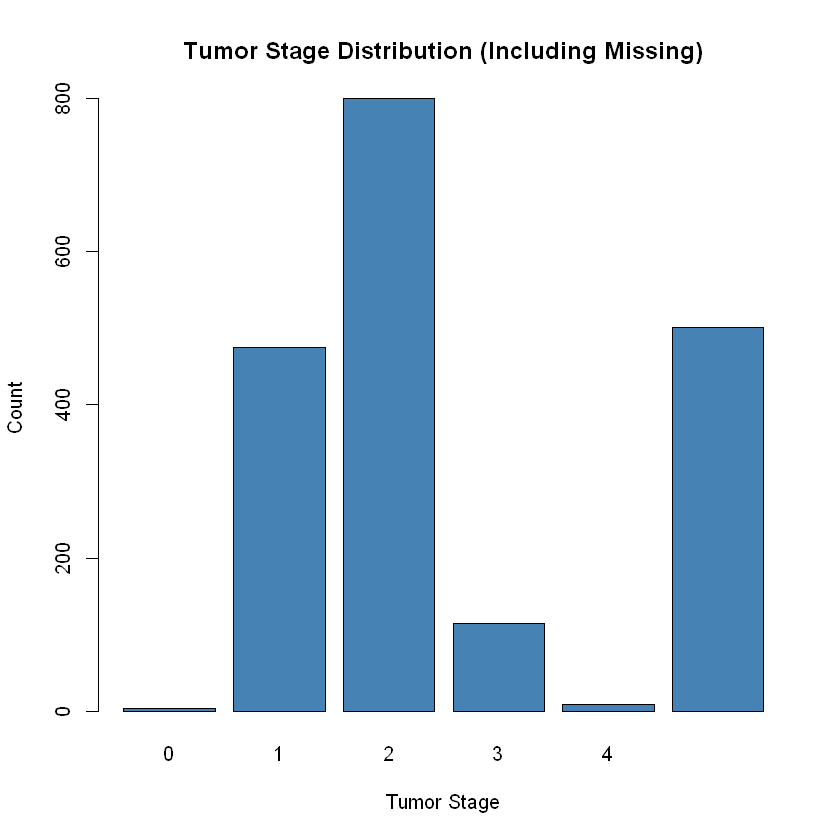

In [13]:
# Missingness distribution for `tumor_stage`

# Table for distribution plot
clinical_stage_counts <- table(addNA(clinical_vars$tumor_stage))

# Visual distribution of tumor stage
barplot(
  clinical_stage_counts,
  main = "Tumor Stage Distribution (Including Missing)",
  xlab = "Tumor Stage",
  ylab = "Count",
  col = "steelblue"
)

In [14]:
# categorical variables count before encoding
clinical_cat_vars <- clinical_vars %>%
  select(where(~ is.character(.) | is.factor(.)))

clinical_cat_vars %>%
  names() %>%
  length()

[1] 17

In [15]:
# Transform categorical variables for modeling
clinical_vars <- clinical_vars %>%
  mutate(across(where(is.character), as.factor))

# Transform numeric categorical variables as factor
clinical_vars <- clinical_vars %>%
  mutate(
    chemotherapy = as.factor(chemotherapy),
    hormone_therapy = as.factor(hormone_therapy),
    radio_therapy = as.factor(radio_therapy),
    tumor_stage = as.factor(tumor_stage),
    cohort = as.factor(cohort)
  )

# categorical variables count after encoding
clinical_vars %>%
  select(where(~ is.character(.) | is.factor(.))) %>%
  names() %>%
  length()

[1] 22

In [16]:
# Distribution of categorical variables

for(x in names(clinical_cat_vars)){
  print(x)
  print(table(clinical_cat_vars[[x]]))
}

[1] "type_of_breast_surgery"

BREAST CONSERVING        MASTECTOMY 
              755              1127 
[1] "cancer_type"

 Breast Cancer Breast Sarcoma 
          1903              1 
[1] "cancer_type_detailed"

                                   Breast 
                                       17 
         Breast Invasive Ductal Carcinoma 
                                     1500 
        Breast Invasive Lobular Carcinoma 
                                      142 
 Breast Invasive Mixed Mucinous Carcinoma 
                                       22 
Breast Mixed Ductal and Lobular Carcinoma 
                                      207 
                Metaplastic Breast Cancer 
                                        1 
[1] "cellularity"

    High      Low Moderate 
     939      200      711 
[1] "pam50_._claudin.low_subtype"

      Basal claudin-low        Her2        LumA        LumB          NC 
        199         199         220         679         461           6 
     Normal 
  

### Decisions
- Impute 26% missingness
- Change empty strings to "Unknown"
- Remove few remainders
- Remove `cancer_type` 'Breast Sarcoma' due to sample size of **1** in with 2nd class at ~1900
- Collapse rare factors later

## Imputation

In [17]:
# Imputation is random sampling
set.seed(2026) 

# Re-define `tumor_stage` as character for imputation
tumor_stage_chr <- as.character(clinical_vars$tumor_stage)

# Pre-imputation distribution of `tumor_stage`
stage_dist <- prop.table(table(tumor_stage_chr, useNA = "no"))
cat("Observed tumor_stage distribution (pre-impute):\n")
print(stage_dist)

# Identify indices of missing `tumor_stage` values
missing_idx <- which(is.na(tumor_stage_chr))

# Impute missing `tumor_stage` values based on observed distribution
tumor_stage_chr[missing_idx] <- sample(
  x = names(stage_dist),
  size = length(missing_idx),
  replace = TRUE,
  prob = as.numeric(stage_dist)
)

# Convert back to factor
clinical_vars$tumor_stage <- factor(tumor_stage_chr)

# Post-imputation distribution of `tumor_stage`
cat("Observed tumor_stage distribution (post-impute):\n")
print(prop.table(table(clinical_vars$tumor_stage, useNA = "ifany")))
cat("\n","Number of missing values after imputation: ", sum(is.na(clinical_vars$tumor_stage)))

Observed tumor_stage distribution (pre-impute):
tumor_stage_chr
          0           1           2           3           4 
0.002851033 0.338560228 0.570206700 0.081967213 0.006414825 
Observed tumor_stage distribution (post-impute):

          0           1           2           3           4 
0.002100840 0.339810924 0.573004202 0.079306723 0.005777311 

 Number of missing values after imputation:  0

In [18]:
# Fill empty "" categorical values with "Unknown" before complete-case filtering
clinical_vars <- clinical_vars %>%
  mutate(
    across(
      where(~ is.factor(.) || is.character(.)),
      ~ {
        if (is.factor(.)) {
          forcats::fct_na_value_to_level(., level = "Unknown")
        } else {
          replace(., is.na(.), "Unknown")
        }
      }
    )
  )

---

# **Pre-processing `gene` predictor variables**

In [19]:
# Quick glance at shape, types, and classes
str(gene_vars)

'data.frame':	1904 obs. of  489 variables:
 $ brca1    : num  -1.399 -1.38 0.067 0.674 1.293 ...
 $ brca2    : num  -0.574 0.278 -0.843 -0.543 -0.904 ...
 $ palb2    : num  -1.622 -1.215 0.211 -1.659 -0.722 ...
 $ pten     : num  1.452 0.53 -0.333 0.637 0.217 ...
 $ tp53     : num  0.3504 -0.0136 0.5141 1.6708 0.3484 ...
 $ atm      : num  1.1517 -0.2659 -0.0803 -0.888 0.3897 ...
 $ cdh1     : num  0.0348 1.3594 1.1398 1.2491 0.9131 ...
 $ chek2    : num  0.127 0.796 0.419 -1.189 0.936 ...
 $ nbn      : num  -0.836 0.542 -0.403 -0.417 0.767 ...
 $ nf1      : num  -0.858 -2.606 -1.131 -0.617 -0.294 ...
 $ stk11    : num  -0.429 0.512 0.236 1.008 -0.296 ...
 $ bard1    : num  -1.12 0.439 -0.172 -0.401 0.632 ...
 $ mlh1     : num  -0.484 1.227 -1.791 -1.391 -0.358 ...
 $ msh2     : num  -0.748 0.761 3.095 4.88 0.303 ...
 $ msh6     : num  -1.666 0.1821 0.6608 0.0615 0.8747 ...
 $ pms2     : num  -0.125 1.01 2.613 2.941 0.632 ...
 $ epcam    : num  -0.372 0.56 2.555 4.116 0.335 ...
 $ rad5

In [20]:
# Check if all gene expression variables are numeric
gene_numerics <- all(sapply(gene_vars, is.numeric))
gene_numerics

[1] TRUE

In [21]:
# Looking at mean and variance of gene expression variables
summary(gene_vars)

     brca1                brca2                palb2           
 Min.   :-2.4444000   Min.   :-2.7835000   Min.   :-4.3846000  
 1st Qu.:-0.7198500   1st Qu.:-0.6994750   1st Qu.:-0.6798250  
 Median :-0.1244500   Median :-0.0582000   Median :-0.0221000  
 Mean   :-0.0000006   Mean   :-0.0000004   Mean   : 0.0000004  
 3rd Qu.: 0.5532250   3rd Qu.: 0.6290000   3rd Qu.: 0.6400000  
 Max.   : 4.5542000   Max.   : 3.7379000   Max.   : 4.6150000  
      pten                 tp53                 atm            
 Min.   :-5.9328000   Min.   :-2.4812000   Min.   :-3.1705000  
 1st Qu.:-0.5586500   1st Qu.:-0.6661500   1st Qu.:-0.6602250  
 Median : 0.1098500   Median :-0.0301000   Median :-0.0042000  
 Mean   :-0.0000009   Mean   : 0.0000006   Mean   :-0.0000002  
 3rd Qu.: 0.6426250   3rd Qu.: 0.6447500   3rd Qu.: 0.6901500  
 Max.   : 3.2541000   Max.   : 4.2898000   Max.   : 3.8242000  
      cdh1                chek2              nbn            
 Min.   :-3.3237000   Min.   :-2.6887   Min

In [22]:
# Scale gene expression variables for modeling
gene_vars_scaled <- scale(gene_vars)
summary(gene_vars_scaled)

     brca1             brca2              palb2               pten        
 Min.   :-2.4438   Min.   :-2.78277   Min.   :-4.38345   Min.   :-5.9312  
 1st Qu.:-0.7197   1st Qu.:-0.69929   1st Qu.:-0.67965   1st Qu.:-0.5585  
 Median :-0.1244   Median :-0.05818   Median :-0.02209   Median : 0.1098  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.5531   3rd Qu.: 0.62884   3rd Qu.: 0.63983   3rd Qu.: 0.6425  
 Max.   : 4.5530   Max.   : 3.73692   Max.   : 4.61379   Max.   : 3.2532  
      tp53               atm                 cdh1             chek2        
 Min.   :-2.48055   Min.   :-3.169668   Min.   :-3.3228   Min.   :-2.6880  
 1st Qu.:-0.66598   1st Qu.:-0.660052   1st Qu.:-0.4585   1st Qu.:-0.7384  
 Median :-0.03009   Median :-0.004199   Median : 0.1155   Median :-0.1311  
 Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.64458   3rd Qu.: 0.689969   3rd Qu.: 0.6496   3rd Qu.: 0.5430  
 Max.   : 4.28867  

In [23]:
# Verify dimensions of scaled gene variables to ensure no data loss during scaling
dim(gene_vars_scaled)

[1] 1904  489

---

# **Pre-processing `mutation` predictor variables**

In [24]:
# Unique values in mutation variables
table_values <- data.frame(table(unlist(mutation_vars)))

# mutation frequency
table_values %>% 
  arrange(desc(Freq)) %>%
  head(10)

n_distinct(table_values)

,Var1,Freq
,<fct>,<int>
1,0,319653
2,H1047R,285
3,E545K,127
4,E542K,73
5,E17K,63
6,X308_splice,59
7,N345K,42
8,K700E,36
9,R175H,34


[1] 7668

In [25]:
# Check missingness in mutation variables
mutation_missing <- data.frame(
  variable = names(mutation_vars),
  missing = colSums(is.na(mutation_vars)),
  missing_pct = round(colMeans(is.na(mutation_vars)) * 100, 3)
)

mutation_missing <- mutation_missing[mutation_missing$missing > 0, ]
mutation_missing

variable,missing,missing_pct
<chr>,<dbl>,<dbl>


In [26]:
# Transform mutation variables to binary (0 = no mutation, 1 = mutation)
mutation_vars_bin <- mutation_vars %>%
  mutate(across(
    everything(),
    ~ {
      x <- as.character(.)
      x <- trimws(x)
      ifelse(x == "0" | is.na(x) | x == "", 0, 1)
    }
  )) %>%
  mutate(across(everything(), as.integer))

In [27]:
# Check unique values after transformation (and distribution)
table(unlist(mutation_vars_bin), useNA = "ifany")


     0      1 
319653   9739 

---

# **Combining back into single df**

In [28]:
# Dimensions need to be consistent across all datasets to merge
nrow(clinical_vars)
nrow(gene_vars_scaled)
nrow(mutation_vars_bin)

[1] 1904

[1] 1904

[1] 1904

In [29]:
# Only processed rows
keep_rows <- complete.cases(
  clinical_vars,
  gene_vars_scaled,
  mutation_vars_bin
)

# Row removals
keep_rows <- keep_rows & clinical_vars$cancer_type != "Breast Sarcoma"

# applying row filter
clinical_vars <- clinical_vars[keep_rows, ]
gene_vars_scaled <- gene_vars_scaled[keep_rows, ]
mutation_vars_bin <- mutation_vars_bin[keep_rows, ]

# Drop unused factor levels left behind after row filtering
clinical_vars <- droplevels(clinical_vars)

# target variables
time_var <- clinical_vars$overall_survival_months
overall_survival_event_var <- clinical_vars$overall_survival

death_from_cancer_event_var <- ifelse(
  clinical_vars$death_from_cancer == "Died of Disease",
  1,
  0
)
death_from_cancer_event_var <- as.numeric(death_from_cancer_event_var)

# Column removals (not useful or harmful to model)
clinical_vars <- clinical_vars %>% 
  select(
    -any_of(c(
      "death_from_cancer", # outcome leak
      "cohort", # groups of people
      "patient_id", # identifier
      "overall_survival", # outcome leak
      "overall_survival_months", # outcome leak
      "nottingham_prognostic_index", # outcome leak - clinical tool used to predict survival 
      "cancer_type" # only 1 cancer type (breast) after filtering, so nothing to split on
    ))
  )

In [30]:
# collapse_rare_levels
collapse_rare_levels <- function(x, min_count = 20) {
  if (!is.factor(x)) return(x)
  
  tab <- table(x)
  rare_levels <- names(tab[tab < min_count])
  
  x <- as.character(x)
  x[x %in% rare_levels] <- "Other"
  factor(x)
}

# only collapse selected high-cardinality factors
collapse_cols <- c(
  "cancer_type_detailed",
  "tumor_other_histologic_subtype",
  "oncotree_code",
  "her2_status_measured_by_snp6"
)

clinical_vars <- clinical_vars %>%
  mutate(across(any_of(collapse_cols), \(x) collapse_rare_levels(x, min_count = 20)))

In [31]:
# Re-combine (standalone)
predictor_df <- data.frame(
  clinical_vars,
  gene_vars_scaled,
  mutation_vars_bin
)

# dataframes for each outcome variable we want to compare models on
overall_survival_df <- data.frame(
  time = time_var,
  event = overall_survival_event_var,
  predictor_df
)

death_from_cancer_df <- data.frame(
  time = time_var,
  event = death_from_cancer_event_var,
  predictor_df
)

---

# Final checks on recombine

In [32]:
# Confirm niche case removal
table(clinical_vars$cancer_type)


         Breast Invasive Ductal Carcinoma 
                                     1409 
        Breast Invasive Lobular Carcinoma 
                                      125 
Breast Mixed Ductal and Lobular Carcinoma 
                                      191 
                                    Other 
                                       45 

In [33]:
# Number and percent of removed rows
sum(!keep_rows)
round(mean(!keep_rows) * 100, 2)

[1] 134

[1] 7.04

In [34]:
# Final dimensions and row alignment
dim(clinical_vars)
dim(gene_vars_scaled)
dim(mutation_vars_bin)
dim(predictor_df)

dim(overall_survival_df)
dim(death_from_cancer_df)

[1] 1770   24

[1] 1770  489

[1] 1770  173

[1] 1770  686

[1] 1770  688

[1] 1770  688

In [35]:
sum(is.na(overall_survival_df))
sum(is.na(death_from_cancer_df))

[1] 0

[1] 0

In [36]:
# Confirm no leakage columns remain
intersect(
  c(
    "death_from_cancer",
    "cohort",
    "patient_id",
    "overall_survival",
    "overall_survival_months",
    "nottingham_prognostic_index",
    "cancer_type"
  ),
  names(predictor_df)
)

character(0)

In [37]:
# Confirm event distribution still looks reasonable
table(overall_survival_event_var)
table(death_from_cancer_event_var)

overall_survival_event_var
   0    1 
1026  744 

death_from_cancer_event_var
   0    1 
1178  592 

In [38]:
# inspect collapsed factor levels
lapply(
  clinical_vars[, sapply(clinical_vars, is.factor), drop = FALSE],
  levels
)

$type_of_breast_surgery
[1] "BREAST CONSERVING" "MASTECTOMY"        "Unknown"          

$cancer_type_detailed
[1] "Breast Invasive Ductal Carcinoma"         
[2] "Breast Invasive Lobular Carcinoma"        
[3] "Breast Mixed Ductal and Lobular Carcinoma"
[4] "Other"                                    

$cellularity
[1] "High"     "Low"      "Moderate" "Unknown" 

$chemotherapy
[1] "0" "1"

$pam50_._claudin.low_subtype
[1] "Basal"       "claudin-low" "Her2"        "LumA"        "LumB"       
[6] "NC"          "Normal"     

$er_status_measured_by_ihc
[1] "Negative" "Positve"  "Unknown" 

$er_status
[1] "Negative" "Positive"

$her2_status_measured_by_snp6
[1] "GAIN"    "LOSS"    "NEUTRAL" "Other"  

$her2_status
[1] "Negative" "Positive"

$tumor_other_histologic_subtype
[1] "Ductal/NST"          "Lobular"             "Medullary"          
[4] "Mixed"               "Other"               "Tubular/ cribriform"

$hormone_therapy
[1] "0" "1"

$inferred_menopausal_state
[1] "Post" "Pre" 

$integrative_cluster
 [1] "1"    "10"   "2"    "3"    "4ER-" "4ER+" "5"    "6"    "7"    "8"   
[11] "9"   

$primary_tumor_laterality
[1] "Left"    "Right"   "Unknown"

$oncotree_code
[1] "IDC"   "ILC"   "MDLC"  "Other"

$pr_status
[1] "Negative" "Positive"

$radio_therapy
[1] "0" "1"

$X3.gene_classifier_subtype
[1] "ER-/HER2-"             "ER+/HER2- High Prolif" "ER+/HER2- Low Prolif" 
[4] "HER2+"                 "Unknown"              

$tumor_stage
[1] "1" "2" "3" "4"

---

# Train/Validate/Test split for models

In [39]:
set.seed(seed)

# same count for both event variables
n <- nrow(overall_survival_df)

# consistent train/validation/test splits for both outcomes since they share the same predictors and time variable
train_idx <- sample(seq_len(n), size = floor(0.8 * n))
temp_idx <- setdiff(seq_len(n), train_idx)
valid_idx <- sample(temp_idx, size = floor(0.5 * length(temp_idx)))
test_idx <- setdiff(temp_idx, valid_idx)

# Overall survival
os_train <- overall_survival_df[train_idx, ]
os_valid <- overall_survival_df[valid_idx, ]
os_test <- overall_survival_df[test_idx, ]

# Death from cancer
dfc_train <- death_from_cancer_df[train_idx, ]
dfc_valid <- death_from_cancer_df[valid_idx, ]
dfc_test <- death_from_cancer_df[test_idx, ]


---

# Bagging 

### Bagging fit

In [ ]:
set.seed(seed)

bag_model_ipred_dfc <- bagging(
  Surv(time, event) ~ .,
  data = dfc_train,
  nbagg = 200,
  coob = TRUE,
  control = rpart.control(xval = 0, cp = 0, minsplit = 20)
)

print(bag_model_ipred_dfc)

In [ ]:
set.seed(seed)

bag_model_ipred_os <- bagging(
  Surv(time, event) ~ .,
  data = os_train,
  nbagg = 200,
  coob = TRUE,
  control = rpart.control(xval = 0, cp = 0, minsplit = 20)
)

print(bag_model_ipred_os)

Brier Score
* approx 0.10-0.15 - very strong
* approx 0.15-0.25 - good
* approx 0.25-0.35 - moderate
* approx greater than 0.35 -weak

### Bagging validation

In [ ]:
# validation predictors
X_valid_dfc <- dfc_valid[, !(names(dfc_valid) %in% c("time", "event"))]

# Predict on validation set
valid_pred_ipred_dfc <- predict(bag_model_ipred_dfc, newdata = X_valid_dfc)

# Validation performance
valid_ibs_dfc <- sbrier(
  Surv(dfc_valid$time, dfc_valid$event),
  valid_pred_ipred_dfc
)

cat("Validation Brier Score:", valid_ibs_dfc, "\n")

In [ ]:
# validation predictors
X_valid_os <- os_valid[, !(names(os_valid) %in% c("time", "event"))]

# Predict on validation set
valid_pred_ipred_os <- predict(bag_model_ipred_os, newdata = X_valid_os)

# Validation performance
valid_ibs_os <- sbrier(
  Surv(os_valid$time, os_valid$event),
  valid_pred_ipred_os
)

cat("Validation Brier Score:", valid_ibs_os, "\n")

0.19 Brier Score strong predictive accuracy

Brier scores < 0.20 = very strong for survival models

### Bagging test

In [ ]:
# test predictors
X_test_dfc <- dfc_test[, !(names(dfc_test) %in% c("time", "event"))]

# Predict on test set
test_pred_ipred_dfc <- predict(bag_model_ipred_dfc, newdata = X_test_dfc)

# Test performance
test_ibs_dfc <- sbrier(
  Surv(dfc_test$time, dfc_test$event),
  test_pred_ipred_dfc
)

cat("Test Brier Score:", test_ibs_dfc, "\n")

In [ ]:
# test predictors
X_test_os <- os_test[, !(names(os_test) %in% c("time", "event"))]

# Predict on test set
test_pred_ipred_os <- predict(bag_model_ipred_os, newdata = X_test_os)

# Test performance
test_ibs_os <- sbrier(
  Surv(os_test$time, os_test$event),
  test_pred_ipred_os
)

cat("Test Brier Score:", test_ibs_os, "\n")

 shows strong predictive performance, with an out-of-bag Brier score of 0.2185  and improved performance on both validation 0.1921 and test 0.1943 datasets. the lower Brier scores on the validation and test sets indicate that the model generalizes well and does not exhibit overfitting

---

# Random Forest

## Fit RF candidate models on train

In [ ]:
# Hyperparameter grid for tuning
rf_grid <- expand.grid(
  mtry = c(25, 50, 100, 200),
  nodesize = c(10, 15, 20, 25),
  ntree = c(125, 250, 500, 1000)
)

In [ ]:
# Training stage result containers
os_rf_train_results <- data.frame()
dfc_rf_train_results <- data.frame()

In [ ]:
# Fit overall survival RF candidates on training data
for (i in seq_len(nrow(rf_grid))) {

  current_rf_mtry <- rf_grid$mtry[i]
  current_rf_nodesize <- rf_grid$nodesize[i]
  current_rf_ntree <- rf_grid$ntree[i]

  os_rf_fit <- rfsrc(
    Surv(time, event) ~ .,
    data = os_train,
    ntree = current_rf_ntree,
    mtry = current_rf_mtry,
    nodesize = current_rf_nodesize,
    importance = FALSE
  )

  os_rf_train_results <- rbind(
    os_rf_train_results,
    data.frame(
      mtry = current_rf_mtry,
      nodesize = current_rf_nodesize,
      ntree = current_rf_ntree,
      train_oob_err = as.numeric(tail(os_rf_fit$err.rate, 1))
    )
  )
}

# Training OOB errors
os_rf_train_results <- os_rf_train_results[order(os_rf_train_results$train_oob_err), ]
os_rf_train_results

In [ ]:
# Fit death from cancer RF candidates on training data
for (i in seq_len(nrow(rf_grid))) {

 current_rf_mtry <- rf_grid$mtry[i]
 current_rf_nodesize <- rf_grid$nodesize[i]
 current_rf_ntree <- rf_grid$ntree[i]

  dfc_fit <- rfsrc(
    Surv(time, event) ~ .,
    data = dfc_train,
    ntree = current_rf_ntree,
    mtry = current_rf_mtry,
    nodesize = current_rf_nodesize,
    importance = FALSE
  )

  dfc_rf_train_results <- rbind(
    dfc_rf_train_results,
    data.frame(
      mtry = current_rf_mtry,
      nodesize = current_rf_nodesize,
      ntree = current_rf_ntree,
      train_oob_err = as.numeric(tail(dfc_fit$err.rate, 1))
    )
  )
}

# Training OOB errors
dfc_rf_train_results <- dfc_rf_train_results[order(dfc_rf_train_results$train_oob_err), ]
dfc_rf_train_results

## Keeping top 3 RF from train

In [ ]:
# Keep the top 3 candidates from training stage for validation testing
os_rf_top3 <- os_rf_train_results[1:3, ]
dfc_rf_top3 <- dfc_rf_train_results[1:3, ]

os_rf_top3
dfc_rf_top3

## Refit top 3 RF on Train and score on Validation

In [ ]:
# Validation stage result containers
os_rf_valid_results <- data.frame()
dfc_rf_valid_results <- data.frame()

In [ ]:
# Fit top overall survival candidates on train, and evaluate on validation
for (i in seq_len(nrow(os_rf_top3))) {

 current_rf_mtry <- os_rf_top3$mtry[i]
 current_rf_nodesize <- os_rf_top3$nodesize[i]
 current_rf_ntree <- os_rf_top3$ntree[i]

  os_rf_fit <- rfsrc(
    Surv(time, event) ~ .,
    data = os_train,
    ntree = current_rf_ntree,
    mtry = current_rf_mtry,
    nodesize = current_rf_nodesize,
    importance = FALSE
  )

  os_rf_pred_valid <- predict(os_rf_fit, newdata = os_valid)

  os_rf_valid_results <- rbind(
    os_rf_valid_results,
    data.frame(
      mtry = current_rf_mtry,
      nodesize = current_rf_nodesize,
      ntree = current_rf_ntree,
      train_oob_err = as.numeric(tail(os_rf_fit$err.rate, 1)),
      valid_err = if (!is.null(os_rf_pred_valid$err.rate) && length(os_rf_pred_valid$err.rate) > 0) { # 
        as.numeric(tail(os_rf_pred_valid$err.rate, 1))
      } else {
        NA_real_
      }
    )
  )
}

# validation errors
os_rf_valid_results <- os_rf_valid_results[order(os_rf_valid_results$valid_err), ]
os_rf_valid_results

In [ ]:
# Fit top death from cancer candidates on train, and evaluate on validation
for (i in seq_len(nrow(dfc_rf_top3))) {

 current_rf_mtry <- dfc_rf_top3$mtry[i]
 current_rf_nodesize <- dfc_rf_top3$nodesize[i]
 current_rf_ntree <- dfc_rf_top3$ntree[i]

  dfc_rf_fit <- rfsrc(
    Surv(time, event) ~ .,
    data = dfc_train,
    ntree = current_rf_ntree,
    mtry = current_rf_mtry,
    nodesize = current_rf_nodesize,
    importance = FALSE
  )

  dfc_rf_pred_valid <- predict(dfc_rf_fit, newdata = dfc_valid)

  dfc_rf_valid_results <- rbind(
    dfc_rf_valid_results,
    data.frame(
      mtry = current_rf_mtry,
      nodesize = current_rf_nodesize,
      ntree = current_rf_ntree,
      train_oob_err = as.numeric(tail(dfc_rf_fit$err.rate, 1)),
      valid_err = if (!is.null(dfc_rf_pred_valid$err.rate) && length(dfc_rf_pred_valid$err.rate) > 0) {
        as.numeric(tail(dfc_rf_pred_valid$err.rate, 1))
      } else {
        NA_real_
      }
    )
  )
}

# validation errors
dfc_rf_valid_results <- dfc_rf_valid_results[order(dfc_rf_valid_results$valid_err), ]
dfc_rf_valid_results

## Refit final RF model on Train + Validation

In [ ]:
# Re-combine train and validation sets for final model fit
os_rf_train_valid <- rbind(os_train, os_valid)
dfc_rf_train_valid <- rbind(dfc_train, dfc_valid)

In [ ]:
# Best overall survival hyperparameters from validation stage
best_os_rf_mtry <- os_rf_valid_results$mtry[1]
best_os_rf_nodesize <- os_rf_valid_results$nodesize[1]
best_os_rf_ntree <- os_rf_valid_results$ntree[1]

# Final overall survival random survival forest
os_rf_final <- rfsrc(
  Surv(time, event) ~ .,
  data = os_rf_train_valid,
  ntree = best_os_rf_ntree,
  mtry = best_os_rf_mtry,
  nodesize = best_os_rf_nodesize,
  importance = TRUE
)

os_rf_final

In [ ]:
# Best death from cancer hyperparameters from validation stage
best_dfc_rf_mtry <- dfc_rf_valid_results$mtry[1]
best_dfc_rf_nodesize <- dfc_rf_valid_results$nodesize[1]
best_dfc_rf_ntree <- dfc_rf_valid_results$ntree[1]

# Final death from cancer random survival forest
dfc_rf_final <- rfsrc(
  Surv(time, event) ~ .,
  data = dfc_rf_train_valid,
  ntree = best_dfc_rf_ntree,
  mtry = best_dfc_rf_mtry,
  nodesize = best_dfc_rf_nodesize,
  importance = TRUE
)

dfc_rf_final

## Final RF Test evaluation

In [ ]:
# Generate test set predictions from final fitted forests
os_rf_pred_test <- predict(os_rf_final, newdata = os_test)
dfc_rf_pred_test <- predict(dfc_rf_final, newdata = dfc_test)

In [ ]:
# error from final forest
os_rf_test_err <- as.numeric(tail(os_rf_pred_test$err.rate, 1))
dfc_rf_test_err <- as.numeric(tail(dfc_rf_pred_test$err.rate, 1))

final_rf_results <- data.frame(
  event_var = c("overall_survival", "death_from_cancer"),
  test_error = c(os_rf_test_err, dfc_rf_test_err)
)

final_rf_results

---

# Boosting

### encode factors into numeric matrices

In [57]:
encode_splits <- function(train_df, valid_df, test_df) {
  
  # predictors only
  train_x <- train_df[, !(names(train_df) %in% c("time", "event")), drop = FALSE]
  valid_x <- valid_df[, !(names(valid_df) %in% c("time", "event")), drop = FALSE]
  test_x  <- test_df[,  !(names(test_df)  %in% c("time", "event")), drop = FALSE]
  
  # remove factor columns with only one observed level in training data
  single_level_cols <- names(train_x)[
    sapply(train_x, function(x) is.factor(x) && nlevels(droplevels(x)) < 2)
  ]
  
  if (length(single_level_cols) > 0) {
    train_x <- train_x[, !(names(train_x) %in% single_level_cols), drop = FALSE]
    valid_x <- valid_x[, !(names(valid_x) %in% single_level_cols), drop = FALSE]
    test_x  <- test_x[,  !(names(test_x)  %in% single_level_cols), drop = FALSE]
  }
  
  # one-hot encode
  train_mat <- model.matrix(~ . - 1, data = train_x)
  valid_mat <- model.matrix(~ . - 1, data = valid_x)
  test_mat  <- model.matrix(~ . - 1, data = test_x)
  
  # align validation/test columns to training columns
  align_to_train <- function(mat, train_cols) {
    
    missing_cols <- setdiff(train_cols, colnames(mat))
    
    if (length(missing_cols) > 0) {
      zero_pad <- matrix(
        0,
        nrow = nrow(mat),
        ncol = length(missing_cols),
        dimnames = list(NULL, missing_cols)
      )
      mat <- cbind(mat, zero_pad)
    }
    
    mat[, train_cols, drop = FALSE]
  }
  
  valid_mat <- align_to_train(valid_mat, colnames(train_mat))
  test_mat  <- align_to_train(test_mat, colnames(train_mat))
  
  list(
    train = train_mat,
    valid = valid_mat,
    test = test_mat
  )
}

# Overall survival encoded matrices
os_mats <- encode_splits(os_train, os_valid, os_test)

# Death-from-cancer encoded matrices
dfc_mats <- encode_splits(dfc_train, dfc_valid, dfc_test)


### Build Cox labels for XGBoost

In [58]:
# event observed  -> positive time
# censored        -> negative time

make_xgb_label <- function(df) {
  ifelse(df$event == 1, df$time, -df$time)
}

# Overall survival DMatrix objects
os_dtrain <- xgb.DMatrix(
  data = os_mats$train,
  label = make_xgb_label(os_train)
)

os_dvalid <- xgb.DMatrix(
  data = os_mats$valid,
  label = make_xgb_label(os_valid)
)

os_dtest <- xgb.DMatrix(
  data = os_mats$test,
  label = make_xgb_label(os_test)
)

# Death-from-cancer DMatrix objects
dfc_dtrain <- xgb.DMatrix(
  data = dfc_mats$train,
  label = make_xgb_label(dfc_train)
)

dfc_dvalid <- xgb.DMatrix(
  data = dfc_mats$valid,
  label = make_xgb_label(dfc_valid)
)

dfc_dtest <- xgb.DMatrix(
  data = dfc_mats$test,
  label = make_xgb_label(dfc_test)
)

### Hyperparameter grid

In [72]:
xgb_grid <- expand.grid(
  eta = c(0.01, 0.03, 0.05),
  max_depth = c(5, 10, 15),
  min_child_weight = c(10, 20, 30),
  subsample = c(0.55, 0.70, 0.85),
  colsample_bytree = c(0.30, 0.50, 0.70)
)

# fixed parameters
base_params <- list(
  objective = "survival:cox",
  eval_metric = "cox-nloglik",
  lambda = 1.0,
  alpha = 0.0,
  tree_method = "hist"
)

### Tune overall survival model on validation set

In [73]:
os_xgb_valid_results <- data.frame()

for (i in seq_len(nrow(xgb_grid))) {
  
  current_eta <- xgb_grid$eta[i]
  current_max_depth <- xgb_grid$max_depth[i]
  current_min_child_weight <- xgb_grid$min_child_weight[i]
  current_subsample <- xgb_grid$subsample[i]
  current_colsample_bytree <- xgb_grid$colsample_bytree[i]
  
  current_params <- c(
    base_params,
    list(
      eta = current_eta,
      max_depth = current_max_depth,
      min_child_weight = current_min_child_weight,
      subsample = current_subsample,
      colsample_bytree = current_colsample_bytree
    )
  )
  
  os_xgb_fit <- xgb.train(
    params = current_params,
    data = os_dtrain,
    nrounds = 500,
    evals = list(train = os_dtrain, valid = os_dvalid),
    early_stopping_rounds = 30,
    verbose = 0
  )
  
  current_eval_log <- attributes(os_xgb_fit)$evaluation_log
  current_valid_curve <- current_eval_log$valid_cox_nloglik
  
  current_best_nrounds <- which.min(current_valid_curve)
  current_valid_nloglik <- min(current_valid_curve)
  
  os_xgb_valid_results <- rbind(
    os_xgb_valid_results,
    data.frame(
      eta = current_eta,
      max_depth = current_max_depth,
      min_child_weight = current_min_child_weight,
      subsample = current_subsample,
      colsample_bytree = current_colsample_bytree,
      best_nrounds = current_best_nrounds,
      valid_nloglik = current_valid_nloglik
    )
  )
}

In [67]:
os_xgb_valid_results <- os_xgb_valid_results[order(os_xgb_valid_results$valid_nloglik), ]
os_xgb_valid_results

,eta,max_depth,min_child_weight,subsample,colsample_bytree,best_nrounds,valid_nloglik
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
15,0.03,4,20,0.85,0.5,65,3.663805
2,0.05,3,10,0.70,0.5,59,3.666364
10,0.05,3,10,0.85,0.5,63,3.671346
26,0.05,3,10,0.85,0.7,56,3.674333
14,0.05,3,20,0.85,0.5,66,3.681119
25,0.03,3,10,0.85,0.7,69,3.681548
7,0.03,4,20,0.70,0.5,85,3.683109
13,0.03,3,20,0.85,0.5,85,3.683671
11,0.03,4,10,0.85,0.5,61,3.688102


### Tune death-from-cancer model on validation set

In [68]:
dfc_xgb_valid_results <- data.frame()

for (i in seq_len(nrow(xgb_grid))) {
  
  current_eta <- xgb_grid$eta[i]
  current_max_depth <- xgb_grid$max_depth[i]
  current_min_child_weight <- xgb_grid$min_child_weight[i]
  current_subsample <- xgb_grid$subsample[i]
  current_colsample_bytree <- xgb_grid$colsample_bytree[i]
  
  current_params <- c(
    base_params,
    list(
      eta = current_eta,
      max_depth = current_max_depth,
      min_child_weight = current_min_child_weight,
      subsample = current_subsample,
      colsample_bytree = current_colsample_bytree
    )
  )
  
  dfc_xgb_fit <- xgb.train(
    params = current_params,
    data = dfc_dtrain,
    nrounds = 500,
    evals = list(train = dfc_dtrain, valid = dfc_dvalid),
    early_stopping_rounds = 30,
    verbose = 0
  )
  
  current_eval_log <- attributes(dfc_xgb_fit)$evaluation_log
  current_valid_curve <- current_eval_log$valid_cox_nloglik
  
  current_best_nrounds <- which.min(current_valid_curve)
  current_valid_nloglik <- min(current_valid_curve)
  
  dfc_xgb_valid_results <- rbind(
    dfc_xgb_valid_results,
    data.frame(
      eta = current_eta,
      max_depth = current_max_depth,
      min_child_weight = current_min_child_weight,
      subsample = current_subsample,
      colsample_bytree = current_colsample_bytree,
      best_nrounds = current_best_nrounds,
      valid_nloglik = current_valid_nloglik
    )
  )
}

In [69]:
dfc_xgb_valid_results <- dfc_xgb_valid_results[order(dfc_xgb_valid_results$valid_nloglik), ]
dfc_xgb_valid_results

,eta,max_depth,min_child_weight,subsample,colsample_bytree,best_nrounds,valid_nloglik
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
30,0.05,3,20,0.85,0.7,126,4.285762
13,0.03,3,20,0.85,0.5,228,4.322506
32,0.05,4,20,0.85,0.7,97,4.323515
15,0.03,4,20,0.85,0.5,114,4.328325
24,0.05,4,20,0.70,0.7,104,4.329017
1,0.03,3,10,0.70,0.5,200,4.330471
10,0.05,3,10,0.85,0.5,144,4.330759
31,0.03,4,20,0.85,0.7,193,4.331967
11,0.03,4,10,0.85,0.5,109,4.333080


### Refit final models on train + validation

In [74]:
os_train_valid <- rbind(os_train, os_valid)
dfc_train_valid <- rbind(dfc_train, dfc_valid)

# Re-encode using train+validation as the training reference
os_final_mats <- encode_splits(os_train_valid, os_test, os_test)
dfc_final_mats <- encode_splits(dfc_train_valid, dfc_test, dfc_test)

os_dtrain_valid <- xgb.DMatrix(
  data = os_final_mats$train,
  label = make_xgb_label(os_train_valid)
)

os_dtest_final <- xgb.DMatrix(
  data = os_final_mats$valid,
  label = make_xgb_label(os_test)
)

dfc_dtrain_valid <- xgb.DMatrix(
  data = dfc_final_mats$train,
  label = make_xgb_label(dfc_train_valid)
)

dfc_dtest_final <- xgb.DMatrix(
  data = dfc_final_mats$valid,
  label = make_xgb_label(dfc_test)
)

In [ ]:
best_os_xgb <- os_xgb_valid_results[1, ]
best_dfc_xgb <- dfc_xgb_valid_results[1, ]

# Final overall survival XGBoost survival model
os_xgb_final <- xgb.train(
  params = c(
    base_params,
    list(
      eta = best_os_xgb$eta,
      max_depth = best_os_xgb$max_depth,
      min_child_weight = best_os_xgb$min_child_weight,
      subsample = best_os_xgb$subsample,
      colsample_bytree = best_os_xgb$colsample_bytree
    )
  ),
  data = os_dtrain_valid,
  nrounds = best_os_xgb$best_nrounds,
  verbose = 0
)

# Final death-from-cancer XGBoost survival model
dfc_xgb_final <- xgb.train(
  params = c(
    base_params,
    list(
      eta = best_dfc_xgb$eta,
      max_depth = best_dfc_xgb$max_depth,
      min_child_weight = best_dfc_xgb$min_child_weight,
      subsample = best_dfc_xgb$subsample,
      colsample_bytree = best_dfc_xgb$colsample_bytree
    )
  ),
  data = dfc_dtrain_valid,
  nrounds = best_dfc_xgb$best_nrounds,
  verbose = 0
)

### Final test-set C-index

In [76]:
os_xgb_test_risk <- predict(os_xgb_final, os_dtest_final)
dfc_xgb_test_risk <- predict(dfc_xgb_final, dfc_dtest_final)

os_xgb_test_cindex <- concordance(
  Surv(os_test$time, os_test$event) ~ os_xgb_test_risk,
  reverse = TRUE
)$concordance

dfc_xgb_test_cindex <- concordance(
  Surv(dfc_test$time, dfc_test$event) ~ dfc_xgb_test_risk,
  reverse = TRUE
)$concordance

final_xgb_results <- data.frame(
  event_var = c("overall_survival", "death_from_cancer"),
  test_cindex = c(os_xgb_test_cindex, dfc_xgb_test_cindex)
)

final_xgb_results

event_var,test_cindex
<chr>,<dbl>
overall_survival,0.7090293
death_from_cancer,0.7549234


---